In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
customers_df = pd.read_csv('/content/olist_customers_dataset.csv')
orders_df = pd.read_csv('/content/olist_orders_dataset.csv')
order_items_df = pd.read_csv('/content/olist_order_items_dataset.csv')
products_df = pd.read_csv('/content/olist_products_dataset.csv')
sellers_df = pd.read_csv('/content/olist_sellers_dataset.csv')
geolocation_df = pd.read_csv('/content/olist_geolocation_dataset.csv')
order_payments_df = pd.read_csv('/content/olist_order_payments_dataset.csv')

/tmp/ipykernel_469/3815826309.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order_status_counts.index, y=order_status_counts.values, palette='viridis')


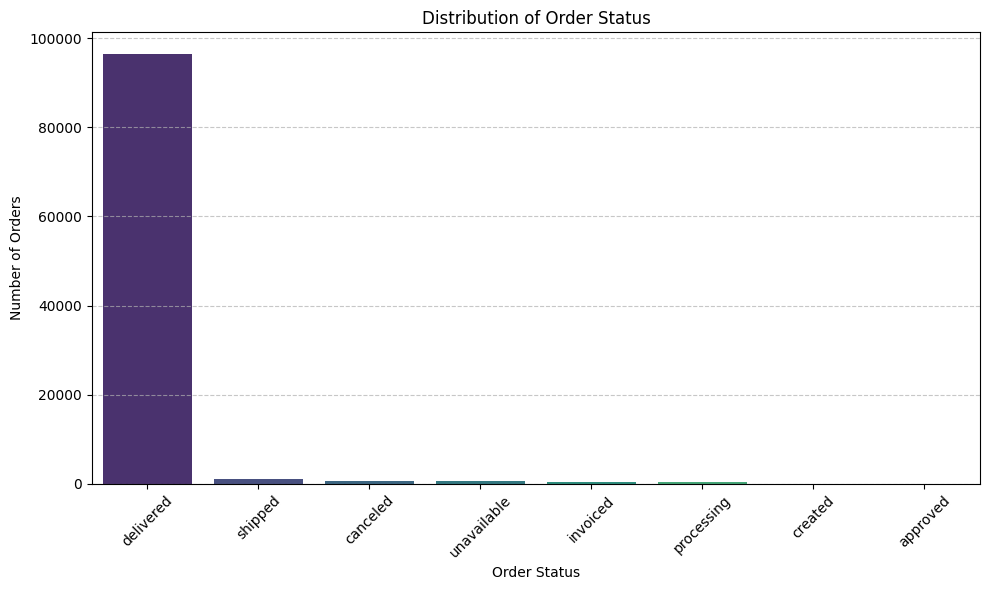

In [4]:
order_status_counts = orders_df['order_status'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=order_status_counts.index, y=order_status_counts.values, palette='viridis')
plt.title('Distribution of Order Status')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

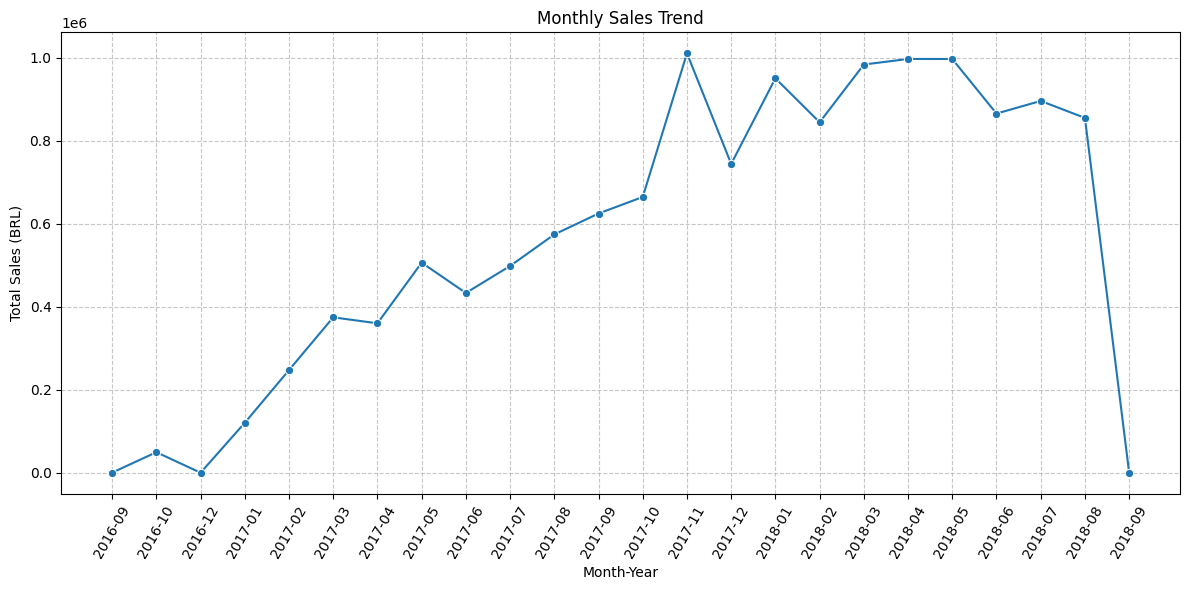

In [5]:
# Convert order_purchase_timestamp to datetime and extract month
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['purchase_month_year'] = orders_df['order_purchase_timestamp'].dt.to_period('M')

# Merge with order_items to get price for sales calculation
sales_df = pd.merge(orders_df, order_items_df, on='order_id')
monthly_sales = sales_df.groupby('purchase_month_year')['price'].sum().reset_index()
monthly_sales['purchase_month_year'] = monthly_sales['purchase_month_year'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(x='purchase_month_year', y='price', data=monthly_sales, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales (BRL)')
plt.xticks(rotation=60)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_469/2146870435.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=customer_state_counts.index, y=customer_state_counts.values, palette='plasma')


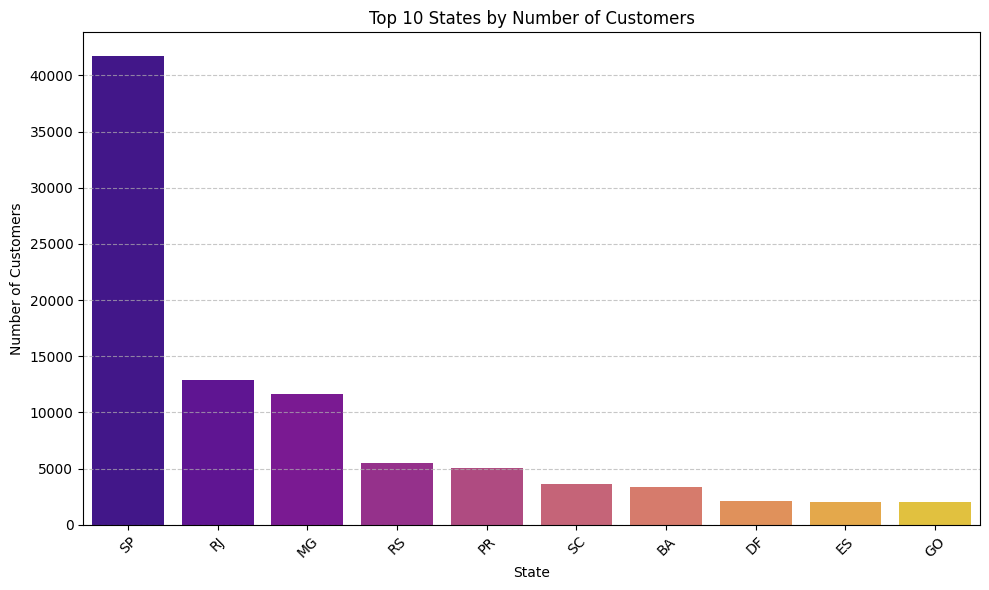

In [6]:
# Count customers by state
customer_state_counts = customers_df['customer_state'].value_counts().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=customer_state_counts.index, y=customer_state_counts.values, palette='plasma')
plt.title('Top 10 States by Number of Customers')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_469/171905351.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='magma')


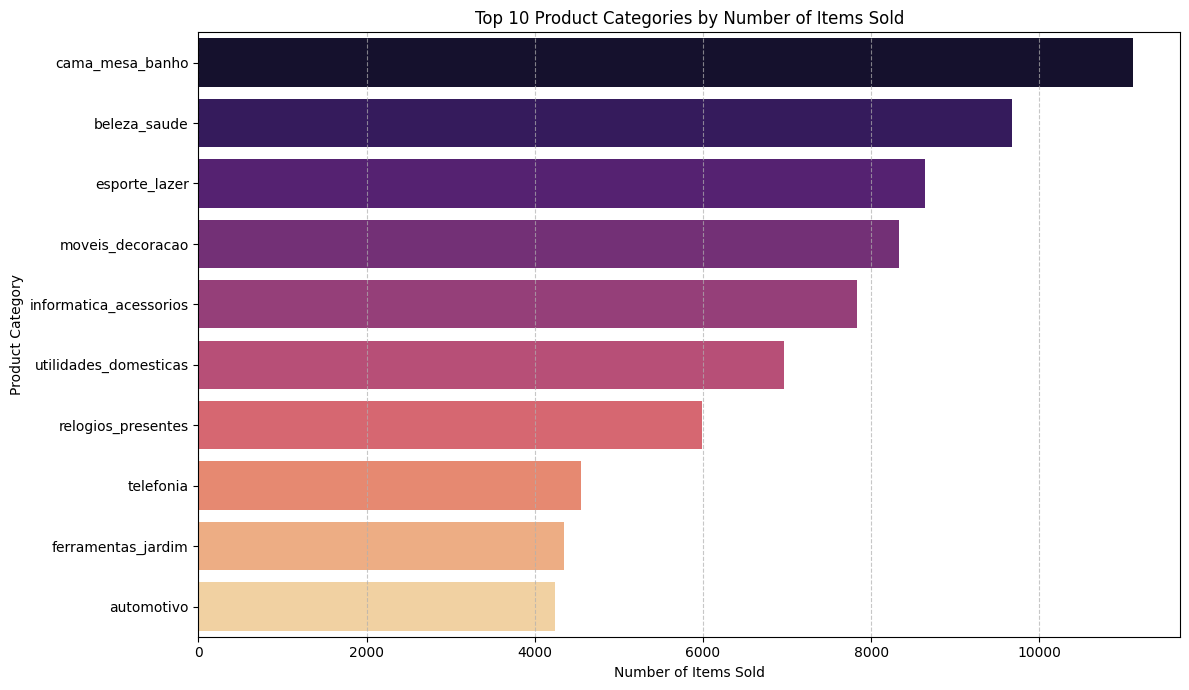

In [7]:
# Merge order_items with products to get product categories
product_categories_df = pd.merge(order_items_df, products_df, on='product_id')

# Count the occurrences of each product category
top_categories = product_categories_df['product_category_name'].value_counts().nlargest(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='magma')
plt.title('Top 10 Product Categories by Number of Items Sold')
plt.xlabel('Number of Items Sold')
plt.ylabel('Product Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

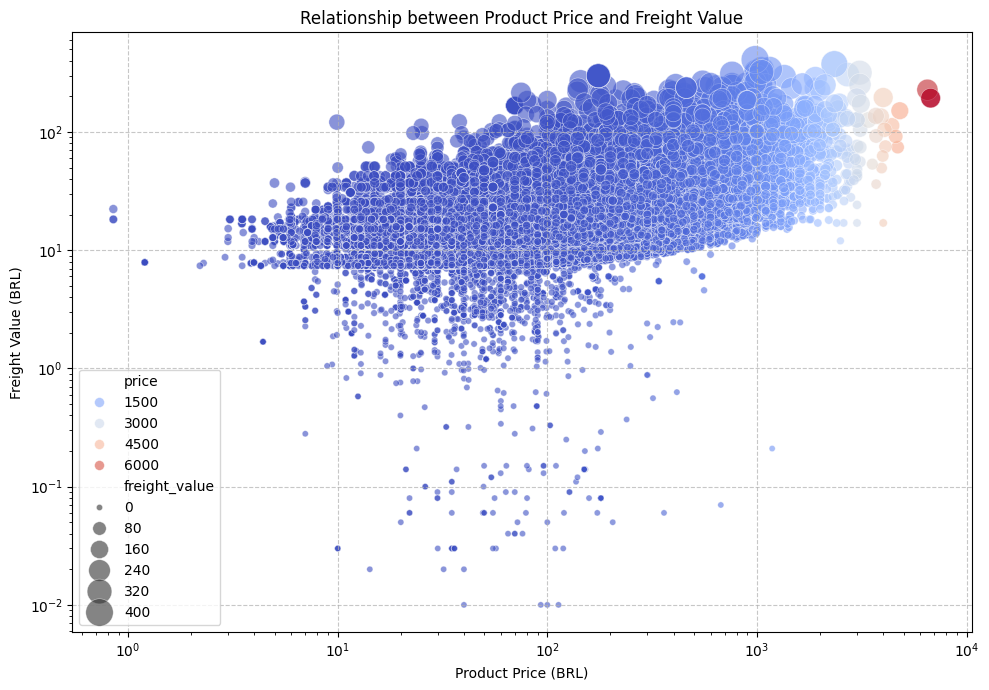

In [8]:
# Create a scatter plot to show the relationship
plt.figure(figsize=(10, 7))
sns.scatterplot(x='price', y='freight_value', data=order_items_df, alpha=0.6, s=50, hue='price', size='freight_value', sizes=(20, 400), palette='coolwarm', legend='brief')
plt.title('Relationship between Product Price and Freight Value')
plt.xlabel('Product Price (BRL)')
plt.ylabel('Freight Value (BRL)')
plt.xscale('log') # Use log scale for price due to wide range
plt.yscale('log') # Use log scale for freight value due to wide range
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()